## Setting up & getting the data

In [174]:
# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [175]:
import os
import tarfile
from six.moves import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = "datasets/housing"
HOUSING_URL = DOWNLOAD_ROOT + HOUSING_PATH + "/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
    
fetch_housing_data()

In [176]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [177]:
housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [178]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [179]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


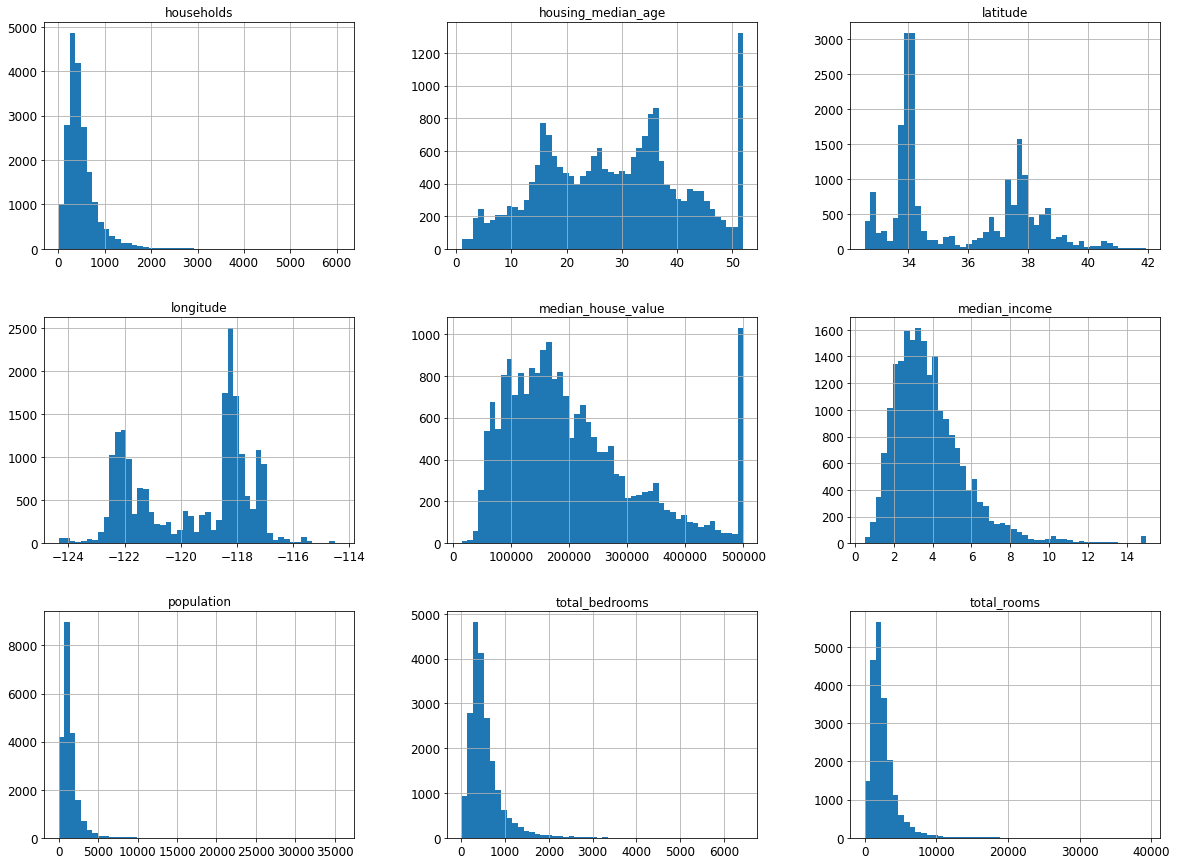

In [180]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [181]:
import numpy as np
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = split_train_test(housing, 0.2)
print(len(train_set), "train +", len(test_set), "test")

16512 train + 4128 test


In [182]:
import hashlib

def test_set_check(identifier, test_ratio, hash):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

def split_train_test_by_id(data, test_ratio, id_column, hash=hashlib.md5):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio, hash))
    return data.loc[~in_test_set], data.loc[in_test_set]


# adds an `index` column to use as identifier for our hashing train/test split mechanism
housing_with_id = housing.reset_index()
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

test_set.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
11,11,-122.26,37.85,52.0,3503.0,752.0,1504.0,734.0,3.2705,241800.0,NEAR BAY
20,20,-122.27,37.85,40.0,751.0,184.0,409.0,166.0,1.3578,147500.0,NEAR BAY
23,23,-122.27,37.84,52.0,1688.0,337.0,853.0,325.0,2.1806,99700.0,NEAR BAY


In [183]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


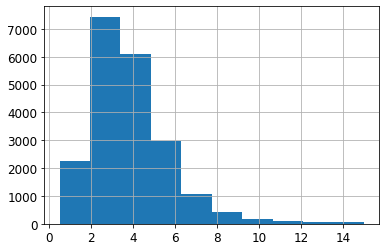

In [184]:
housing["median_income"].hist()

In [185]:
# Divide by 1.5 to limit the number of income categories
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
# Label those above 5 as 5
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)
housing["income_cat"].value_counts()

3.0    7236
2.0    6581
4.0    3639
5.0    2362
1.0     822
Name: income_cat, dtype: int64

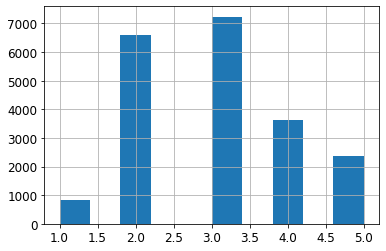

In [186]:
housing["income_cat"].hist()

In [187]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]
    
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114583
1.0    0.039729
Name: income_cat, dtype: float64

In [188]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
1.0,0.039826,0.039729,0.040213,0.973236,-0.243309
2.0,0.318847,0.318798,0.324370,1.732260,-0.015195
3.0,0.350581,0.350533,0.358527,2.266446,-0.013820
4.0,0.176308,0.176357,0.167393,-5.056334,0.027480
5.0,0.114438,0.114583,0.109496,-4.318374,0.127011


In [189]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## Discover and visualize data to gain insights

In [190]:
housing = strat_train_set.copy()

Saving figure bad_visualization_plot


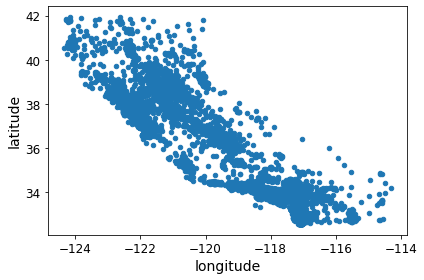

In [191]:
housing.plot(kind="scatter", x="longitude", y="latitude")
save_fig("bad_visualization_plot")

Saving figure better_visualization_plot


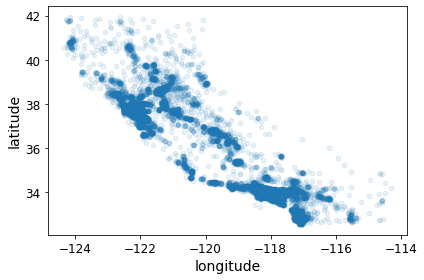

In [192]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)
save_fig("better_visualization_plot")

Saving figure housing_prices_scatterplot


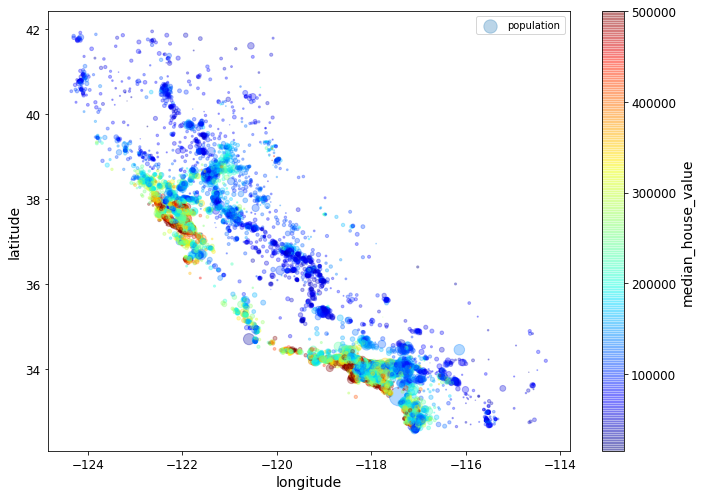

In [193]:
fig, ax = plt.subplots(figsize=(10,7))

housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.3,
    s=housing["population"]/100, label="population", figsize=(10,7),
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True, ax=ax)
plt.legend()
save_fig("housing_prices_scatterplot")

Saving figure california_housing_prices_plot


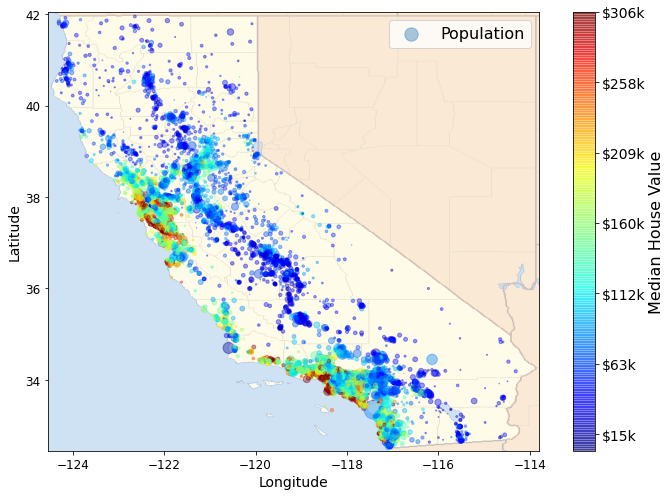

In [194]:
import matplotlib.image as mpimg
california_img=mpimg.imread(PROJECT_ROOT_DIR + '/images/end_to_end_project/california.png')
ax = housing.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                       s=housing['population']/100, label="Population",
                       c="median_house_value", cmap=plt.get_cmap("jet"),
                       colorbar=False, alpha=0.4,
                      )
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = housing["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar()
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)
save_fig("california_housing_prices_plot")
plt.show()

In [195]:
corr_matrix = housing.corr()

In [196]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687160
total_rooms           0.135097
housing_median_age    0.114110
households            0.064506
total_bedrooms        0.047689
population           -0.026920
longitude            -0.047432
latitude             -0.142724
Name: median_house_value, dtype: float64

Saving figure scatter_matrix_plot


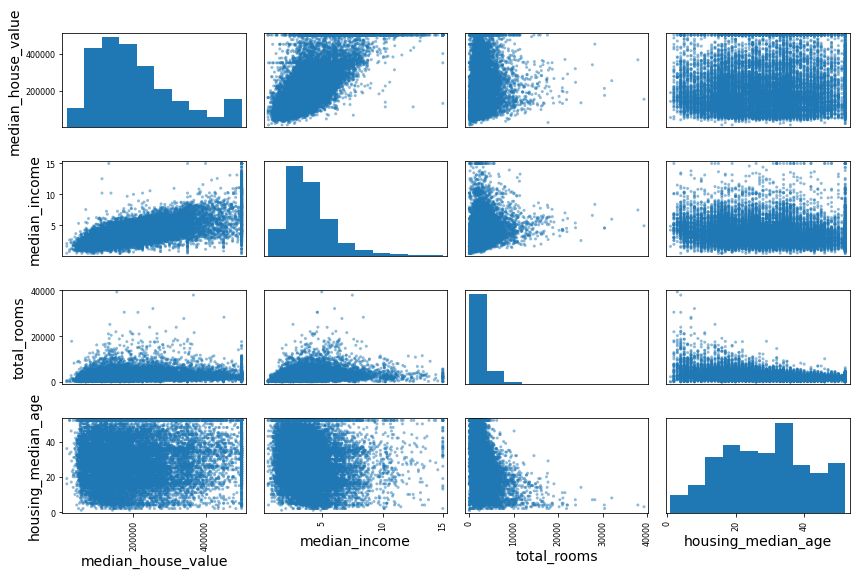

In [197]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")


In [198]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]

In [199]:
corr_matrix = housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value     1.000000
median_income          0.687160
rooms_per_household    0.146285
total_rooms            0.135097
housing_median_age     0.114110
households             0.064506
total_bedrooms         0.047689
population            -0.026920
longitude             -0.047432
latitude              -0.142724
bedrooms_per_room     -0.259984
Name: median_house_value, dtype: float64

In [200]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room
count,16512.000000,16512.000000,16512.000000,16512.000000,16354.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16354.000000
mean,-119.575834,35.639577,28.653101,2622.728319,534.973890,1419.790819,497.060380,3.875589,206990.920724,5.440341,0.212878
std,2.001860,2.138058,12.574726,2138.458419,412.699041,1115.686241,375.720845,1.904950,115703.014830,2.611712,0.057379
min,-124.350000,32.540000,1.000000,6.000000,2.000000,3.000000,2.000000,0.499900,14999.000000,1.130435,0.100000
25%,-121.800000,33.940000,18.000000,1443.000000,295.000000,784.000000,279.000000,2.566775,119800.000000,4.442040,0.175304
50%,-118.510000,34.260000,29.000000,2119.500000,433.000000,1164.000000,408.000000,3.540900,179500.000000,5.232284,0.203031
75%,-118.010000,37.720000,37.000000,3141.000000,644.000000,1719.250000,602.000000,4.744475,263900.000000,6.056361,0.239831
max,-114.310000,41.950000,52.000000,39320.000000,6210.000000,35682.000000,5358.000000,15.000100,500001.000000,141.909091,1.000000


# Prepare the Data for ML algorithms

In [201]:
housing = strat_train_set.drop(["median_house_value", "latitude"], axis=1) # drop labels for training set
housing_labels = strat_train_set["median_house_value"].copy()

In [202]:
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows

,longitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
4629,-118.30,18.0,3759.0,NaN,3296.0,1462.0,2.2708,<1H OCEAN
6068,-117.86,16.0,4632.0,NaN,3038.0,727.0,5.1762,<1H OCEAN
17923,-121.97,30.0,1955.0,NaN,999.0,386.0,4.6328,<1H OCEAN
13656,-117.30,6.0,2155.0,NaN,1039.0,391.0,1.6675,INLAND
19252,-122.79,7.0,6837.0,NaN,3468.0,1405.0,3.1662,<1H OCEAN


In [203]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=[np.number]) # remove non numeric b/c can't compute median if not num

In [204]:
housing_num

,longitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
17606,-121.89,38.0,1568.0,351.0,710.0,339.0,2.7042
18632,-121.93,14.0,679.0,108.0,306.0,113.0,6.4214
14650,-117.20,31.0,1952.0,471.0,936.0,462.0,2.8621
3230,-119.61,25.0,1847.0,371.0,1460.0,353.0,1.8839
3555,-118.59,17.0,6592.0,1525.0,4459.0,1463.0,3.0347
...,...,...,...,...,...,...,...
6563,-118.13,46.0,1271.0,236.0,573.0,210.0,4.9312
12053,-117.56,40.0,1196.0,294.0,1052.0,258.0,2.0682
13908,-116.40,9.0,4855.0,872.0,2098.0,765.0,3.2723
11159,-118.01,31.0,1960.0,380.0,1356.0,356.0,4.0625


In [205]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [206]:
# median of each attribute
imputer.statistics_

array([-118.51  ,   29.    , 2119.5   ,  433.    , 1164.    ,  408.    ,
          3.5409])

In [207]:
housing_num.median().values

array([-118.51  ,   29.    , 2119.5   ,  433.    , 1164.    ,  408.    ,
          3.5409])

In [208]:
# transform the training set
X = imputer.transform(housing_num)

X

array([[-1.2189e+02,  3.8000e+01,  1.5680e+03, ...,  7.1000e+02,
         3.3900e+02,  2.7042e+00],
       [-1.2193e+02,  1.4000e+01,  6.7900e+02, ...,  3.0600e+02,
         1.1300e+02,  6.4214e+00],
       [-1.1720e+02,  3.1000e+01,  1.9520e+03, ...,  9.3600e+02,
         4.6200e+02,  2.8621e+00],
       ...,
       [-1.1640e+02,  9.0000e+00,  4.8550e+03, ...,  2.0980e+03,
         7.6500e+02,  3.2723e+00],
       [-1.1801e+02,  3.1000e+01,  1.9600e+03, ...,  1.3560e+03,
         3.5600e+02,  4.0625e+00],
       [-1.2245e+02,  5.2000e+01,  3.0950e+03, ...,  1.2690e+03,
         6.3900e+02,  3.5750e+00]])

In [209]:
# convert back into DF
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing.index)
# should be no NaN values now
housing_tr.loc[sample_incomplete_rows.index.values]

,longitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
4629,-118.30,18.0,3759.0,433.0,3296.0,1462.0,2.2708
6068,-117.86,16.0,4632.0,433.0,3038.0,727.0,5.1762
17923,-121.97,30.0,1955.0,433.0,999.0,386.0,4.6328
13656,-117.30,6.0,2155.0,433.0,1039.0,391.0,1.6675
19252,-122.79,7.0,6837.0,433.0,3468.0,1405.0,3.1662


In [210]:
# now preprocess the categorical data into numerical form
housing_cat = housing[['ocean_proximity']]
housing_cat.head(10)

,ocean_proximity
17606,<1H OCEAN
18632,<1H OCEAN
14650,NEAR OCEAN
3230,INLAND
3555,<1H OCEAN
19480,INLAND
8879,<1H OCEAN
13685,INLAND
4937,<1H OCEAN
4861,<1H OCEAN


In [211]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[0.],
       [0.],
       [4.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.]])

In [212]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [213]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

In [214]:
housing.columns

Index(['longitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
       'population', 'households', 'median_income', 'ocean_proximity'],
      dtype='object')

In [215]:
from sklearn.base import BaseEstimator, TransformerMixin

# get the right column indices: safer than hard-coding indices 3, 4, 5, 6
rooms_ix, bedrooms_ix, household_ix = [
    list(housing.columns).index(col)
    for col in ("total_rooms", "total_bedrooms", "households")]

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kwargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, household_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household]

attr_adder = CombinedAttributesAdder()
housing_extra_attribs = attr_adder.transform(housing.values)
housing_extra_attribs

array([[-121.89, 38.0, 1568.0, ..., '<1H OCEAN', 4.625368731563422,
        0.22385204081632654],
       [-121.93, 14.0, 679.0, ..., '<1H OCEAN', 6.008849557522124,
        0.15905743740795286],
       [-117.2, 31.0, 1952.0, ..., 'NEAR OCEAN', 4.225108225108225,
        0.24129098360655737],
       ...,
       [-116.4, 9.0, 4855.0, ..., 'INLAND', 6.34640522875817,
        0.1796086508753862],
       [-118.01, 31.0, 1960.0, ..., '<1H OCEAN', 5.50561797752809,
        0.19387755102040816],
       [-122.45, 52.0, 3095.0, ..., 'NEAR BAY', 4.843505477308295,
        0.22035541195476574]], dtype=object)

In [216]:
housing_extra_attribs = pd.DataFrame(
    housing_extra_attribs,
    columns=list(housing.columns)+["rooms_per_household", "bedrooms_per_room"],
    index=housing.index)
housing_extra_attribs.head()

,longitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room
17606,-121.89,38,1568,351,710,339,2.7042,<1H OCEAN,4.62537,0.223852
18632,-121.93,14,679,108,306,113,6.4214,<1H OCEAN,6.00885,0.159057
14650,-117.2,31,1952,471,936,462,2.8621,NEAR OCEAN,4.22511,0.241291
3230,-119.61,25,1847,371,1460,353,1.8839,INLAND,5.23229,0.200866
3555,-118.59,17,6592,1525,4459,1463,3.0347,<1H OCEAN,4.50581,0.231341


In [217]:
housing_num

,longitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
17606,-121.89,38.0,1568.0,351.0,710.0,339.0,2.7042
18632,-121.93,14.0,679.0,108.0,306.0,113.0,6.4214
14650,-117.20,31.0,1952.0,471.0,936.0,462.0,2.8621
3230,-119.61,25.0,1847.0,371.0,1460.0,353.0,1.8839
3555,-118.59,17.0,6592.0,1525.0,4459.0,1463.0,3.0347
...,...,...,...,...,...,...,...
6563,-118.13,46.0,1271.0,236.0,573.0,210.0,4.9312
12053,-117.56,40.0,1196.0,294.0,1052.0,258.0,2.0682
13908,-116.40,9.0,4855.0,872.0,2098.0,765.0,3.2723
11159,-118.01,31.0,1960.0,380.0,1356.0,356.0,4.0625


In [218]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
    ])

housing_numerical_transformed = num_pipeline.fit_transform(housing_num)
housing_numerical_transformed

array([[-1.15604281,  0.74333089, -0.49323393, ..., -0.61493744,
        -0.31205452,  0.15531753],
       [-1.17602483, -1.1653172 , -0.90896655, ...,  1.33645936,
         0.21768338, -0.83628902],
       [ 1.18684903,  0.18664186, -0.31365989, ..., -0.5320456 ,
        -0.46531516,  0.4222004 ],
       ...,
       [ 1.58648943, -1.56295222,  1.04390119, ..., -0.3167053 ,
         0.3469342 , -0.52177644],
       [ 0.78221312,  0.18664186, -0.30991876, ...,  0.09812139,
         0.02499488, -0.30340741],
       [-1.43579109,  1.85670895,  0.22085348, ..., -0.15779865,
        -0.22852947,  0.10180567]])

In [219]:
from sklearn.compose import ColumnTransformer

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ])

housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared

array([[-1.15604281,  0.74333089, -0.49323393, ...,  0.        ,
         0.        ,  0.        ],
       [-1.17602483, -1.1653172 , -0.90896655, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.18684903,  0.18664186, -0.31365989, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 1.58648943, -1.56295222,  1.04390119, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.78221312,  0.18664186, -0.30991876, ...,  0.        ,
         0.        ,  0.        ],
       [-1.43579109,  1.85670895,  0.22085348, ...,  0.        ,
         1.        ,  0.        ]])

In [220]:
housing_prepared.shape

(16512, 14)

# Time to select and train some models!!

In [221]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [222]:
# let's try the full preprocessing pipeline on a few training instances
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [202482.96101874 303973.41770674 213028.26419148  50650.99872868
 188663.67579498]


In [223]:
# Compare against actual values
print("Labels:", list(some_labels))

Labels: [286600.0, 340600.0, 196900.0, 46300.0, 254500.0]


In [224]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

69769.00755503343

In [225]:
from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(housing_labels, housing_predictions)
lin_mae

49956.33645191716

In [226]:
from sklearn.model_selection import cross_val_score

lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(lin_rmse_scores)

Scores: [68052.37466542 67781.28970296 70883.56289553 75768.77763111
 69115.98359962 72469.23378536 66091.8876849  69236.63464785
 72339.96453179 69113.5788982 ]
Mean: 70085.3288042719
Standard deviation: 2677.6563244037184


In [227]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=10, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

RandomForestRegressor(n_estimators=10, random_state=42)

In [228]:
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

24624.75007239711

In [229]:
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [55793.69702337 54451.66210964 57212.21937827 58974.0271467
 56505.57314689 61129.49357752 56907.71273684 58979.23741282
 60476.67832215 58637.27837174]
Mean: 57906.757922592995
Standard deviation: 1991.4808367353012


In [230]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training 
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [231]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

In [232]:
grid_search.best_estimator_

RandomForestRegressor(max_features=6, n_estimators=30, random_state=42)

In [233]:
cv_res = grid_search.cv_results_
for mean_score, params in zip(cv_res["mean_test_score"], cv_res["params"]):
    print(np.sqrt(-mean_score), params)

70021.437226323 {'max_features': 2, 'n_estimators': 3}
60631.941745194614 {'max_features': 2, 'n_estimators': 10}
57910.475429603466 {'max_features': 2, 'n_estimators': 30}
66502.96365442104 {'max_features': 4, 'n_estimators': 3}
58683.32096940125 {'max_features': 4, 'n_estimators': 10}
56388.50173946683 {'max_features': 4, 'n_estimators': 30}
65564.64739853998 {'max_features': 6, 'n_estimators': 3}
58074.11752038462 {'max_features': 6, 'n_estimators': 10}
56080.602823532405 {'max_features': 6, 'n_estimators': 30}
65307.32801883909 {'max_features': 8, 'n_estimators': 3}
58553.26389569698 {'max_features': 8, 'n_estimators': 10}
56430.182300959335 {'max_features': 8, 'n_estimators': 30}
68754.20403257494 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
60086.538936253346 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
66037.98584725759 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
58239.34205628407 {'bootstrap': False, 'max_features': 3, 'n_estimators':

In [234]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([1.05401316e-01, 5.46747183e-02, 3.14853575e-02, 3.31779667e-02,
       4.76370799e-02, 2.99232575e-02, 3.56498108e-01, 7.94656624e-02,
       7.66390615e-02, 1.89961043e-02, 1.52100443e-01, 5.79353402e-05,
       4.84772004e-03, 9.09526942e-03])

In [235]:
extra_attribs = ["rooms_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(0.3564981084699232, 'median_income'),
 (0.15210044278957252, 'INLAND'),
 (0.10540131568246894, 'longitude'),
 (0.07946566241398971, 'rooms_per_hhold'),
 (0.07663906154961213, 'bedrooms_per_room'),
 (0.05467471830258862, 'housing_median_age'),
 (0.04763707992134129, 'population'),
 (0.03317796673354293, 'total_bedrooms'),
 (0.03148535753877986, 'total_rooms'),
 (0.029923257525425927, 'households'),
 (0.01899610427167094, '<1H OCEAN'),
 (0.009095269421792989, 'NEAR OCEAN'),
 (0.004847720039055892, 'NEAR BAY'),
 (5.79353402352384e-05, 'ISLAND')]

In [236]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_rmse

/Users/michaelchen/.local/share/virtualenvs/hands-on-with-ml-xI9Nv3kk/lib/python3.8/site-packages/sklearn/compose/_column_transformer.py:437: FutureWarning: Given feature/column names or counts do not match the ones for the data given during fit. This will fail from v0.24.
  warnings.warn("Given feature/column names or counts do not match "


53623.84951146002

# A "full" pipeline example

In [237]:
full_pipeline_with_predictor = Pipeline([
        ("preparation", full_pipeline),
        ("linear", LinearRegression())
    ])

full_pipeline_with_predictor.fit(housing, housing_labels)
full_pipeline_with_predictor.predict(some_data)

array([202482.96101874, 303973.41770674, 213028.26419148,  50650.99872868,
       188663.67579498])

In [238]:
# improve by picking "top features"
from sklearn.base import BaseEstimator, TransformerMixin

def indices_of_top_k(arr, k):
    return np.sort(np.argpartition(np.array(arr), -k)[-k:])

class TopFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_importances, k):
        self.feature_importances = feature_importances
        self.k = k
    def fit(self, X, y=None):
        self.feature_indices_ = indices_of_top_k(self.feature_importances, self.k)
        return self
    def transform(self, X):
        return X[:, self.feature_indices_]

In [239]:
k = 5
preparation_and_feature_selection_pipeline = Pipeline([
    ('preparation', full_pipeline),
    ('feature_selection', TopFeatureSelector(feature_importances, k))
])

In [240]:
housing_prepared_top_k_features = preparation_and_feature_selection_pipeline.fit_transform(housing)
housing_prepared_top_k_features[0:3]

array([[-1.15604281, -0.61493744, -0.31205452,  0.15531753,  0.        ],
       [-1.17602483,  1.33645936,  0.21768338, -0.83628902,  0.        ],
       [ 1.18684903, -0.5320456 , -0.46531516,  0.4222004 ,  0.        ]])

In [241]:
# double check these are indeed the top features
top_k_feature_indices = indices_of_top_k(feature_importances, k)
print(top_k_feature_indices)

housing_prepared[0:3, top_k_feature_indices]

[ 0  6  7  8 10]


array([[-1.15604281, -0.61493744, -0.31205452,  0.15531753,  0.        ],
       [-1.17602483,  1.33645936,  0.21768338, -0.83628902,  0.        ],
       [ 1.18684903, -0.5320456 , -0.46531516,  0.4222004 ,  0.        ]])

In [242]:
sorted(zip(feature_importances, attributes), reverse=True)[:k]

[(0.3564981084699232, 'median_income'),
 (0.15210044278957252, 'INLAND'),
 (0.10540131568246894, 'longitude'),
 (0.07946566241398971, 'rooms_per_hhold'),
 (0.07663906154961213, 'bedrooms_per_room')]

In [243]:
prepare_select_and_predict_pipeline = Pipeline([
    ('preparation', full_pipeline),
    ('feature_selection', TopFeatureSelector(feature_importances, k)),
    ('rf_reg', grid_search.best_estimator_)
])

In [244]:
param_grid = [{
    'preparation__num__imputer__strategy': ['mean', 'median', 'most_frequent'],
    'feature_selection__k': list(range(1, len(feature_importances) + 1))
}]

grid_search_prep = GridSearchCV(prepare_select_and_predict_pipeline, param_grid, cv=5,
                                scoring='neg_mean_squared_error', verbose=2, n_jobs=4)
grid_search_prep.fit(housing, housing_labels)

Fitting 5 folds for each of 42 candidates, totalling 210 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  38 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done 210 out of 210 | elapsed:  1.0min finished


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preparation',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('attribs_adder',
                                                                                          CombinedAttributesAdder()),
                                                                                         ('std_scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'housing_median_age

In [245]:
grid_search_prep.best_params_

{'feature_selection__k': 14, 'preparation__num__imputer__strategy': 'median'}

In [246]:
len(feature_importances)

14

So apparently all 14 of 14 features are important...